# 015. word2vec 작성

- skipgram, window size 2 의 simplified word2vec model 작성

## 요약 (※ 순서를 지키지 않으면 한글 출력이 제대로 이루어지지 않을 수 있습니다.) 

1. Google Colab의 노트북에서 위의 코드를 먼저 한번 실행 (폰트 설치 단계)  
2. 그 후 런타임 다시 시작 (설치된 폰트 적용 준비)  
3. 다시 위의 코드를 실행 (폰트 적용)  
4. 그 후 그래프 출력 코드 실행 (한글 정상 출력)  

In [28]:
# # 한글폰트 사용 in colab
# %matplotlib inline  

# import matplotlib as mpl 
# import matplotlib.pyplot as plt 
# import matplotlib.font_manager as fm  

# !apt-get update -qq
# !apt-get install fonts-nanum* -qq

# path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' 
# font_name = fm.FontProperties(fname=path, size=10).get_name()
# print(font_name)
# plt.rc('font', family=font_name)

# fm._rebuild()
# mpl.rcParams['axes.unicode_minus'] = False

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
import numpy as np
import re

### Toy 말뭉치

In [29]:
corpus = ['king is a very strong man', 
          'queen is a wise and pretty woman', 
          'boy is a young man',
          'girl is a young and pretty woman',
          'prince is young and will be a strong and wise king',
          'princess is a young woman and will be a pretty and wise queen',
          'man is strong', 
          'woman is pretty',
          'prince is a boy will be a king',
          'princess is a girl will be a queen']

# corpus = ['왕은 매우 강한 남자이다', 
#           '여왕은 현명한 예쁜 여자이다', 
#           '소년은 젊은 남자이다',
#           '소녀는 젊은 예쁜 여자이다',
#           '왕자는 젊고 현명한 왕이 될 것이다',
#           '공주는 젊고 예쁜 현명한 여왕이 될 것이다',
#           '남자는 강하다', 
#           '여자는 예쁘다',
#           '왕자는 왕이 될 소년이다',
#           '공주는 왕비가 될 소녀이다']

In [30]:
cleaned_corpus = []
for text in corpus:
    text = re.sub(r'[^a-zA-Z ]', '', text)   #영문
    # text = re.sub(r'[^가-힣 ]', '', text)        #한글
    cleaned_corpus.append(text.lower())
            
cleaned_corpus

['king is a very strong man',
 'queen is a wise and pretty woman',
 'boy is a young man',
 'girl is a young and pretty woman',
 'prince is young and will be a strong and wise king',
 'princess is a young woman and will be a pretty and wise queen',
 'man is strong',
 'woman is pretty',
 'prince is a boy will be a king',
 'princess is a girl will be a queen']

In [32]:
stop_words = ['is', 'a' ,'will', 'be', 'and']
# stop_words = ['은', '가', '이다', '는', '이', '될']

results = []
    
for text in corpus:
    tmp = []
    for word in text.split():
        if word not in stop_words:
            tmp.append(word)
    results.append(' '.join(tmp))

### vocaburary 모음 작성

In [33]:
words = []

for sentence in cleaned_corpus:
    for word in sentence.split(' '):
        words.append(word)

words = set(words)

### word-to-index, index-to-word 작성

- word 를 index 로 변환  

- sentence 를 word index 로 변환  

- window size 에 따라 train data 생성

In [34]:
word2index = dict((w, i) for i, w in enumerate(words))
index2word = dict((i, w) for i, w in enumerate(words))

In [35]:
word2index

{'a': 13,
 'and': 8,
 'be': 12,
 'boy': 2,
 'girl': 11,
 'is': 16,
 'king': 6,
 'man': 17,
 'pretty': 15,
 'prince': 10,
 'princess': 3,
 'queen': 9,
 'strong': 14,
 'very': 5,
 'will': 7,
 'wise': 4,
 'woman': 1,
 'young': 0}

### skip-gram 으로 training data 생성

In [37]:
sentences = []
for sentence in cleaned_corpus:
    sentences.append(sentence.split())
sentences

[['king', 'is', 'a', 'very', 'strong', 'man'],
 ['queen', 'is', 'a', 'wise', 'and', 'pretty', 'woman'],
 ['boy', 'is', 'a', 'young', 'man'],
 ['girl', 'is', 'a', 'young', 'and', 'pretty', 'woman'],
 ['prince',
  'is',
  'young',
  'and',
  'will',
  'be',
  'a',
  'strong',
  'and',
  'wise',
  'king'],
 ['princess',
  'is',
  'a',
  'young',
  'woman',
  'and',
  'will',
  'be',
  'a',
  'pretty',
  'and',
  'wise',
  'queen'],
 ['man', 'is', 'strong'],
 ['woman', 'is', 'pretty'],
 ['prince', 'is', 'a', 'boy', 'will', 'be', 'a', 'king'],
 ['princess', 'is', 'a', 'girl', 'will', 'be', 'a', 'queen']]

In [38]:
WINDOW_SIZE = 2

data = []
for sentence in sentences:
    for idx, word in enumerate(sentence):
        for neighbor in sentence[max(idx - WINDOW_SIZE, 0) : min(idx + WINDOW_SIZE, len(sentence)) + 1] : 
            if neighbor != word:
                data.append([word, neighbor])

In [39]:
data[:10]

[['king', 'is'],
 ['king', 'a'],
 ['is', 'king'],
 ['is', 'a'],
 ['is', 'very'],
 ['a', 'king'],
 ['a', 'is'],
 ['a', 'very'],
 ['a', 'strong'],
 ['very', 'is']]

In [40]:
import pandas as pd

df = pd.DataFrame(data, columns = ['input', 'label'])
df.head()

,input,label
0,king,is
1,king,a
2,is,king
3,is,a
4,is,very


### One hot encoding

In [41]:
from tensorflow.keras.utils import to_categorical

len(words)

18

### One hot encoding 된 train, label data

In [42]:
X = [] # input word
Y = [] # target word

for x, y in zip(df['input'], df['label']):
    X.append(to_categorical(word2index[x], len(words)))
    Y.append(to_categorical(word2index[x], len(words)))

In [43]:
print(X[:3])
print(Y[:3])

[array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.], dtype=float32), array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0.], dtype=float32)]
[array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.], dtype=float32), array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0.], dtype=float32)]


In [44]:
# convert them to numpy arrays
X_train = np.array(X)
Y_train = np.array(Y)

**시각화를 위해 hidden layer 의 unit 을 2 로 제한**

In [45]:
model = Sequential()
model.add(Dense(2, input_dim=len(words)))
model.add(Dense(len(words)))

model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])

In [46]:
model.fit(X_train, Y_train, epochs=50, batch_size=3)

Epoch 1/50
75/75 [==============================] - 1s 1ms/step - loss: 5.3387 - accuracy: 0.1071
Epoch 2/50
75/75 [==============================] - 0s 2ms/step - loss: 6.4770 - accuracy: 0.1071
Epoch 3/50
75/75 [==============================] - 0s 1ms/step - loss: 7.2675 - accuracy: 0.1071
Epoch 4/50
75/75 [==============================] - 0s 1ms/step - loss: 7.2675 - accuracy: 0.1071
Epoch 5/50
75/75 [==============================] - 0s 1ms/step - loss: 7.2675 - accuracy: 0.1071
Epoch 6/50
75/75 [==============================] - 0s 1ms/step - loss: 7.2675 - accuracy: 0.1071
Epoch 7/50
75/75 [==============================] - 0s 1ms/step - loss: 7.2675 - accuracy: 0.1071
Epoch 8/50
75/75 [==============================] - 0s 1ms/step - loss: 7.2675 - accuracy: 0.1071
Epoch 9/50
75/75 [==============================] - 0s 1ms/step - loss: 7.2675 - accuracy: 0.1071
Epoch 10/50
75/75 [==============================] - 0s 1ms/step - loss: 7.2675 - accuracy: 0.1071
Epoch 11/50
75/75 [

### 첫번째 Hidden Layer 추출 및 weight + bias 를 vector 로 합산

In [47]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 2)                 38        
                                                                 
 dense_3 (Dense)             (None, 18)                54        
                                                                 
Total params: 92
Trainable params: 92
Non-trainable params: 0
_________________________________________________________________


In [48]:
model.layers[0].get_weights()

[array([[-0.46491668,  0.03204857],
        [ 0.30909935,  0.15185425],
        [ 0.39233708,  0.17128712],
        [ 0.39790767, -0.53468174],
        [ 0.3216365 ,  0.281909  ],
        [-0.4571137 , -0.06147173],
        [-0.42937514,  0.46379423],
        [ 0.5332098 ,  0.09229332],
        [-0.08853058,  0.28805646],
        [-0.22022545,  0.04690278],
        [-0.44879007,  0.0486176 ],
        [-0.00932746, -0.4231839 ],
        [ 0.06857268, -0.11131623],
        [ 0.5447406 ,  0.1242673 ],
        [-0.10900567, -0.01621198],
        [-0.14671177,  0.0044657 ],
        [-0.22733235, -0.49204335],
        [-0.3319166 , -0.5340179 ]], dtype=float32),
 array([-0.00031873, -0.00900394], dtype=float32)]

In [49]:
model.layers[0].get_weights()[1]

array([-0.00031873, -0.00900394], dtype=float32)

In [50]:
vectors= model.layers[0].get_weights()[0] + model.layers[0].get_weights()[1]
vectors[:5]

array([[-0.4652354 ,  0.02304463],
       [ 0.3087806 ,  0.14285031],
       [ 0.39201835,  0.16228318],
       [ 0.39758894, -0.5436857 ],
       [ 0.32131776,  0.27290505]], dtype=float32)

In [51]:
w2v = pd.DataFrame(vectors, columns = ['x1', 'x2'])
w2v['word'] = list(words)
w2v['x1'] *= 10
w2v['x2'] *= 10
w2v

,x1,x2,word
0,-4.652354,0.230446,young
1,3.087806,1.428503,woman
2,3.920183,1.622832,boy
3,3.975889,-5.436857,princess
4,3.213178,2.729051,wise
5,-4.574325,-0.704757,very
6,-4.296939,4.547903,king
7,5.328911,0.832894,will
8,-0.888493,2.790525,and
9,-2.205442,0.378988,queen


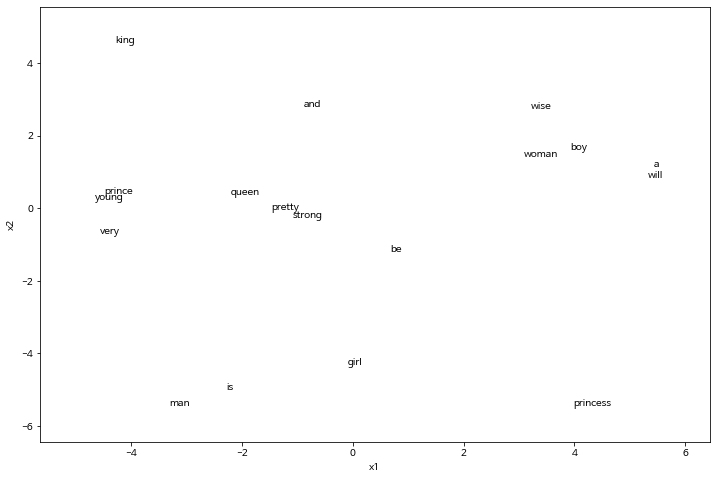

In [52]:
import matplotlib.pyplot as plt
%matplotlib inline
#한글 폰트 사용
# from matplotlib import font_manager
# import matplotlib
# font_path = "C:/Windows/Fonts/H2GTRM.TTF"                       #폰트 경로
# font_name = font_manager.FontProperties(fname=font_path).get_name()  #폰트 이름 얻어오기
# matplotlib.rc('font', family=font_name)                                 #font 지정
# matplotlib.rcParams['axes.unicode_minus'] = False               #한글사용시 마이너스 사인 깨짐 방지

fig, ax = plt.subplots(figsize=(12,8))

for word, x1, x2 in zip(w2v['word'], w2v['x1'], w2v['x2']):
    ax.annotate(word, (x1, x2))
    
PADDING = 1.0
x_axis_min = np.min(vectors, axis=0)[0] - PADDING
y_axis_min = np.min(vectors, axis=0)[1] - PADDING
x_axis_max = np.max(vectors, axis=0)[0] + PADDING
y_axis_max = np.max(vectors, axis=0)[1] + PADDING
 
plt.xlim(x_axis_min, x_axis_max)
plt.ylim(y_axis_min, y_axis_max)
plt.xlabel('x1')
plt.ylabel('x2')

plt.show()